In [1]:
import pandas as pd

df = pd.read_csv('data/data_science_salaries.csv')

print("Shape of dataset:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape of dataset: (6599, 11)

Column names: ['job_title', 'experience_level', 'employment_type', 'work_models', 'work_year', 'employee_residence', 'salary', 'salary_currency', 'salary_in_usd', 'company_location', 'company_size']

First 5 rows:


,job_title,experience_level,employment_type,work_models,work_year,employee_residence,salary,salary_currency,salary_in_usd,company_location,company_size
0,Data Engineer,Mid-level,Full-time,Remote,2024,United States,148100,USD,148100,United States,Medium
1,Data Engineer,Mid-level,Full-time,Remote,2024,United States,98700,USD,98700,United States,Medium
2,Data Scientist,Senior-level,Full-time,Remote,2024,United States,140032,USD,140032,United States,Medium
3,Data Scientist,Senior-level,Full-time,Remote,2024,United States,100022,USD,100022,United States,Medium
4,BI Developer,Mid-level,Full-time,On-site,2024,United States,120000,USD,120000,United States,Medium


In [2]:
# Check data types and missing values
print(df.info())
print("\nMissing values per column:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6599 entries, 0 to 6598
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   job_title           6599 non-null   object
 1   experience_level    6599 non-null   object
 2   employment_type     6599 non-null   object
 3   work_models         6599 non-null   object
 4   work_year           6599 non-null   int64 
 5   employee_residence  6599 non-null   object
 6   salary              6599 non-null   int64 
 7   salary_currency     6599 non-null   object
 8   salary_in_usd       6599 non-null   int64 
 9   company_location    6599 non-null   object
 10  company_size        6599 non-null   object
dtypes: int64(3), object(8)
memory usage: 567.2+ KB
None

Missing values per column:
job_title             0
experience_level      0
employment_type       0
work_models           0
work_year             0
employee_residence    0
salary                0
salary_currency 

In [3]:
df.describe()

,work_year,salary,salary_in_usd
count,6599.000000,6.599000e+03,6599.000000
mean,2022.818457,1.792833e+05,145560.558569
std,0.674809,5.263722e+05,70946.838070
min,2020.000000,1.400000e+04,15000.000000
25%,2023.000000,9.600000e+04,95000.000000
50%,2023.000000,1.400000e+05,138666.000000
75%,2023.000000,1.875000e+05,185000.000000
max,2024.000000,3.040000e+07,750000.000000


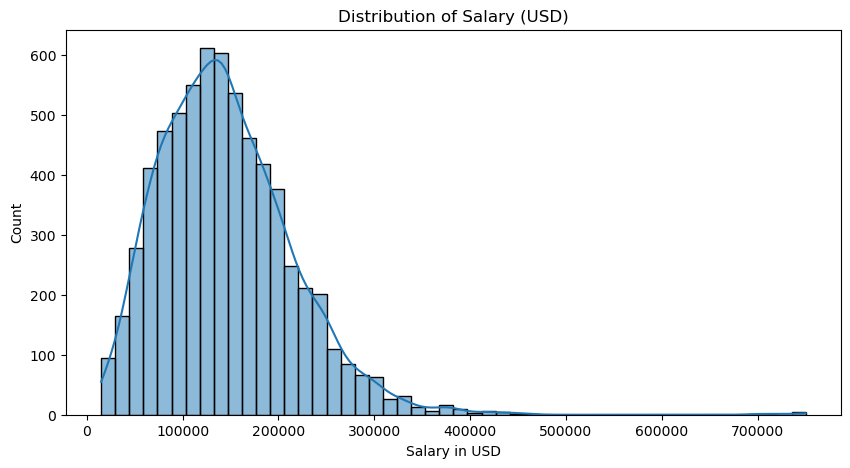

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(df['salary_in_usd'], bins=50, kde=True)
plt.title('Distribution of Salary (USD)')
plt.xlabel('Salary in USD')
plt.ylabel('Count')
plt.show()

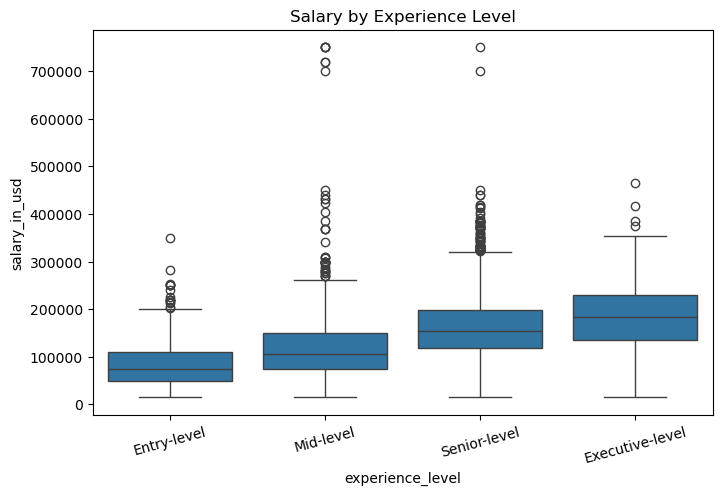

In [5]:
# Salary by experience level
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='experience_level', y='salary_in_usd', 
            order=['Entry-level','Mid-level','Senior-level','Executive-level'])
plt.title('Salary by Experience Level')
plt.xticks(rotation=15)
plt.show()

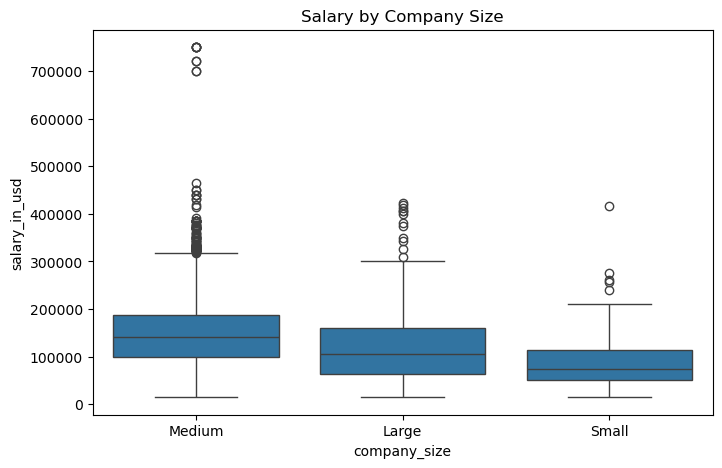

In [6]:
# Salary by company size
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='company_size', y='salary_in_usd')
plt.title('Salary by Company Size')
plt.show()

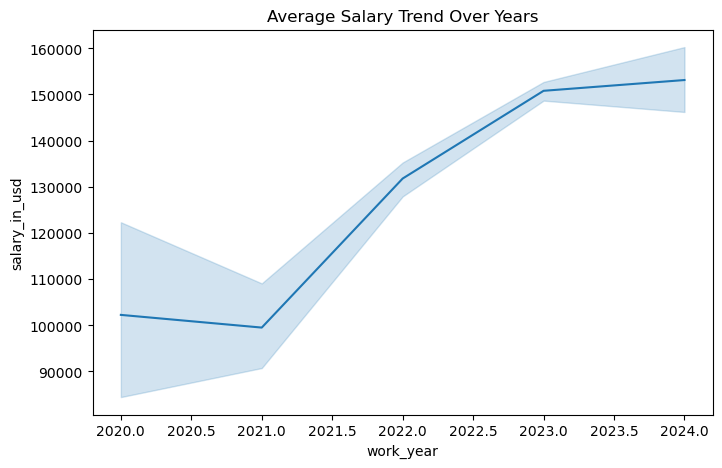

In [7]:
# Salary trend over years
plt.figure(figsize=(8,5))
sns.lineplot(data=df, x='work_year', y='salary_in_usd', estimator='mean')
plt.title('Average Salary Trend Over Years')
plt.show()

In [8]:
print(df['job_title'].nunique(), "unique job titles")
df['job_title'].value_counts().head(15)

132 unique job titles


job_title
Data Engineer                     1307
Data Scientist                    1243
Data Analyst                       910
Machine Learning Engineer          629
Analytics Engineer                 246
Research Scientist                 206
Data Architect                     176
Research Engineer                  136
ML Engineer                        113
Applied Scientist                   97
Data Science Manager                86
Business Intelligence Analyst       82
Machine Learning Scientist          73
Business Intelligence Engineer      69
Data Manager                        63
Name: count, dtype: int64

In [9]:
# Group rare job titles into 'Other'
title_counts = df['job_title'].value_counts()
top_titles = title_counts[title_counts >= 50].index  # keep titles with 50+ occurrences

df['job_title_grouped'] = df['job_title'].apply(lambda x: x if x in top_titles else 'Other')

print(df['job_title_grouped'].nunique(), "grouped job titles")
df['job_title_grouped'].value_counts()

18 grouped job titles


job_title_grouped
Data Engineer                     1307
Data Scientist                    1243
Other                             1047
Data Analyst                       910
Machine Learning Engineer          629
Analytics Engineer                 246
Research Scientist                 206
Data Architect                     176
Research Engineer                  136
ML Engineer                        113
Applied Scientist                   97
Data Science Manager                86
Business Intelligence Analyst       82
Machine Learning Scientist          73
Business Intelligence Engineer      69
Data Manager                        63
Research Analyst                    60
Data Science                        56
Name: count, dtype: int64

In [10]:
# Check top 1% of salaries
threshold = df['salary_in_usd'].quantile(0.99)
print(f"99th percentile salary: ${threshold:,.0f}")
print(f"Number of rows above this: {(df['salary_in_usd'] > threshold).sum()}")

df[df['salary_in_usd'] > threshold][['job_title', 'experience_level', 'salary_in_usd']]

99th percentile salary: $345,012
Number of rows above this: 66


,job_title,experience_level,salary_in_usd
82,Machine Learning Engineer,Senior-level,418000
84,Research Engineer,Senior-level,440000
111,Data Engineer,Senior-level,385000
113,Data Scientist,Mid-level,385000
129,Research Engineer,Mid-level,440000
...,...,...,...
6120,Data Analyst,Mid-level,430967
6388,Principal Data Scientist,Executive-level,416000
6403,Applied Machine Learning Scientist,Mid-level,423000
6529,Research Scientist,Mid-level,450000


In [11]:
# salary and salary_currency are redundant now that we have salary_in_usd
df_clean = df.drop(columns=['salary', 'salary_currency', 'job_title'])
df_clean.head()

,experience_level,employment_type,work_models,work_year,employee_residence,salary_in_usd,company_location,company_size,job_title_grouped
0,Mid-level,Full-time,Remote,2024,United States,148100,United States,Medium,Data Engineer
1,Mid-level,Full-time,Remote,2024,United States,98700,United States,Medium,Data Engineer
2,Senior-level,Full-time,Remote,2024,United States,140032,United States,Medium,Data Scientist
3,Senior-level,Full-time,Remote,2024,United States,100022,United States,Medium,Data Scientist
4,Mid-level,Full-time,On-site,2024,United States,120000,United States,Medium,Other


In [12]:
print("Unique employee_residence:", df_clean['employee_residence'].nunique())
print("Unique company_location:", df_clean['company_location'].nunique())

Unique employee_residence: 87
Unique company_location: 75


In [13]:
def group_rare_categories(df, col, threshold=50):
    counts = df[col].value_counts()
    keep = counts[counts >= threshold].index
    return df[col].apply(lambda x: x if x in keep else 'Other')

df_clean['employee_residence_grouped'] = group_rare_categories(df_clean, 'employee_residence')
df_clean['company_location_grouped'] = group_rare_categories(df_clean, 'company_location')

df_clean = df_clean.drop(columns=['employee_residence', 'company_location'])

print(df_clean['employee_residence_grouped'].nunique(), "grouped residences")
print(df_clean['company_location_grouped'].nunique(), "grouped company locations")

8 grouped residences
7 grouped company locations


In [14]:
experience_order = {'Entry-level': 0, 'Mid-level': 1, 'Senior-level': 2, 'Executive-level': 3}
df_clean['experience_level_encoded'] = df_clean['experience_level'].map(experience_order)

company_size_order = {'Small': 0, 'Medium': 1, 'Large': 2}
df_clean['company_size_encoded'] = df_clean['company_size'].map(company_size_order)

df_clean = df_clean.drop(columns=['experience_level', 'company_size'])

In [15]:
experience_order = {'Entry-level': 0, 'Mid-level': 1, 'Senior-level': 2, 'Executive-level': 3}
df_clean['experience_level_encoded'] = df_clean['experience_level'].map(experience_order)

company_size_order = {'Small': 0, 'Medium': 1, 'Large': 2}
df_clean['company_size_encoded'] = df_clean['company_size'].map(company_size_order)

df_clean = df_clean.drop(columns=['experience_level', 'company_size'])

KeyError: 'experience_level'

In [16]:
categorical_cols = ['job_title_grouped', 'employment_type', 'work_models', 
                     'employee_residence_grouped', 'company_location_grouped']

df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

print("Final shape after encoding:", df_encoded.shape)
df_encoded.head()

Final shape after encoding: (6599, 39)


,work_year,salary_in_usd,experience_level_encoded,company_size_encoded,job_title_grouped_Applied Scientist,job_title_grouped_Business Intelligence Analyst,job_title_grouped_Business Intelligence Engineer,job_title_grouped_Data Analyst,job_title_grouped_Data Architect,job_title_grouped_Data Engineer,...,employee_residence_grouped_Other,employee_residence_grouped_Spain,employee_residence_grouped_United Kingdom,employee_residence_grouped_United States,company_location_grouped_Germany,company_location_grouped_India,company_location_grouped_Other,company_location_grouped_Spain,company_location_grouped_United Kingdom,company_location_grouped_United States
0,2024,148100,1,1,False,False,False,False,False,True,...,False,False,False,True,False,False,False,False,False,True
1,2024,98700,1,1,False,False,False,False,False,True,...,False,False,False,True,False,False,False,False,False,True
2,2024,140032,2,1,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
3,2024,100022,2,1,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
4,2024,120000,1,1,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True


In [17]:
from sklearn.model_selection import train_test_split
import numpy as np

X = df_encoded.drop(columns=['salary_in_usd'])
y = df_encoded['salary_in_usd']

# Log-transform the target (recall our right-skew finding from Phase 2)
y_log = np.log1p(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (5279, 38)
Test shape: (1320, 38)


In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_log = lr_model.predict(X_test)

# Convert back from log scale to real dollars for interpretable metrics
y_pred = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)

mae = mean_absolute_error(y_test_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
r2 = r2_score(y_test_actual, y_pred)

print(f"MAE:  ${mae:,.0f}")
print(f"RMSE: ${rmse:,.0f}")
print(f"R²:   {r2:.3f}")

MAE:  $42,738
RMSE: $64,093
R²:   0.301


In [19]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_log_rf = rf_model.predict(X_test)
y_pred_rf = np.expm1(y_pred_log_rf)

mae_rf = mean_absolute_error(y_test_actual, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_actual, y_pred_rf))
r2_rf = r2_score(y_test_actual, y_pred_rf)

print(f"Random Forest — MAE:  ${mae_rf:,.0f}")
print(f"Random Forest — RMSE: ${rmse_rf:,.0f}")
print(f"Random Forest — R²:   {r2_rf:.3f}")

Random Forest — MAE:  $43,246
Random Forest — RMSE: $63,871
Random Forest — R²:   0.306


In [20]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae, mae_rf],
    'RMSE': [rmse, rmse_rf],
    'R²': [r2, r2_rf]
})
print(comparison)

               Model           MAE          RMSE        R²
0  Linear Regression  42737.665392  64093.438929  0.301009
1      Random Forest  43246.127812  63870.533720  0.305863


                                        feature  importance
31     employee_residence_grouped_United States    0.332765
1                      experience_level_encoded    0.230057
6                job_title_grouped_Data Analyst    0.064118
0                                     work_year    0.054765
2                          company_size_encoded    0.037142
33               company_location_grouped_India    0.028801
14  job_title_grouped_Machine Learning Engineer    0.023094
23                          work_models_On-site    0.022668
24                           work_models_Remote    0.018919
28             employee_residence_grouped_Other    0.018491
16                      job_title_grouped_Other    0.017826
35               company_location_grouped_Spain    0.013868
19         job_title_grouped_Research Scientist    0.013015
34               company_location_grouped_Other    0.011924
12             job_title_grouped_Data Scientist    0.010485


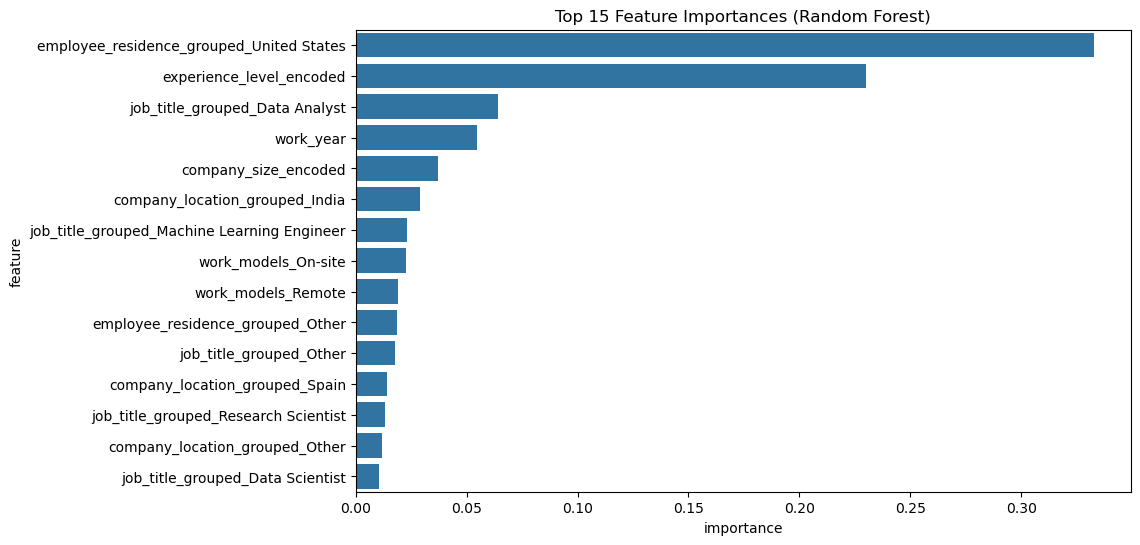

In [21]:
importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(importances.head(15))

plt.figure(figsize=(10,6))
sns.barplot(data=importances.head(15), x='importance', y='feature')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.show()

In [22]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=15,
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)
search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV R²:", search.best_score_)

Best params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10}
Best CV R²: 0.4596962453481193


In [23]:
best_rf = search.best_estimator_

y_pred_log_best = best_rf.predict(X_test)
y_pred_best = np.expm1(y_pred_log_best)

mae_best = mean_absolute_error(y_test_actual, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test_actual, y_pred_best))
r2_best = r2_score(y_test_actual, y_pred_best)

print(f"Tuned RF — MAE:  ${mae_best:,.0f}")
print(f"Tuned RF — RMSE: ${rmse_best:,.0f}")
print(f"Tuned RF — R²:   {r2_best:.3f}")

# Update comparison table
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest (default)', 'Random Forest (tuned)'],
    'MAE': [mae, mae_rf, mae_best],
    'RMSE': [rmse, rmse_rf, rmse_best],
    'R²': [r2, r2_rf, r2_best]
})
print(comparison)

Tuned RF — MAE:  $42,762
Tuned RF — RMSE: $64,066
Tuned RF — R²:   0.302
                     Model           MAE          RMSE        R²
0        Linear Regression  42737.665392  64093.438929  0.301009
1  Random Forest (default)  43246.127812  63870.533720  0.305863
2    Random Forest (tuned)  42761.773741  64066.192636  0.301603


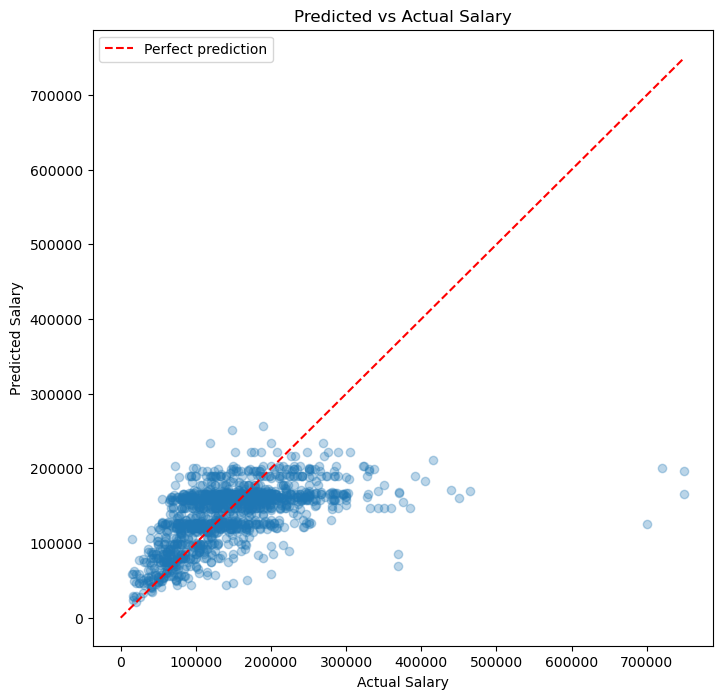

Worst 5 predictions:
        actual      predicted          error      abs_error
1040  750000.0  165338.116503 -584661.883497  584661.883497
726   700000.0  126164.163960 -573835.836040  573835.836040
367   750000.0  197096.897133 -552903.102867  552903.102867
997   720000.0  200387.783332 -519612.216668  519612.216668
473   369120.0   69844.329449 -299275.670551  299275.670551


In [24]:
# Compare predicted vs actual on test set
results_df = pd.DataFrame({
    'actual': y_test_actual.values,
    'predicted': y_pred_best,
})
results_df['error'] = results_df['predicted'] - results_df['actual']
results_df['abs_error'] = results_df['error'].abs()

plt.figure(figsize=(8,8))
plt.scatter(results_df['actual'], results_df['predicted'], alpha=0.3)
plt.plot([0, 750000], [0, 750000], 'r--', label='Perfect prediction')
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Predicted vs Actual Salary')
plt.legend()
plt.show()

print("Worst 5 predictions:")
print(results_df.sort_values('abs_error', ascending=False).head())

In [25]:
import joblib

joblib.dump(best_rf, 'salary_model.pkl')
joblib.dump(X_train.columns.tolist(), 'model_columns.pkl')

print("Model and column list saved!")

Model and column list saved!


In [27]:
print([c.replace('employee_residence_grouped_', '') for c in model_columns if c.startswith('employee_residence_grouped_')])
print([c.replace('company_location_grouped_', '') for c in model_columns if c.startswith('company_location_grouped_')])

NameError: name 'model_columns' is not defined

In [28]:
import joblib
model_columns = joblib.load('model_columns.pkl')

print([c.replace('employee_residence_grouped_', '') for c in model_columns if c.startswith('employee_residence_grouped_')])
print([c.replace('company_location_grouped_', '') for c in model_columns if c.startswith('company_location_grouped_')])

['France', 'Germany', 'India', 'Other', 'Spain', 'United Kingdom', 'United States']
['Germany', 'India', 'Other', 'Spain', 'United Kingdom', 'United States']


In [29]:
print(sorted(df_clean['employee_residence_grouped'].unique()))
print(sorted(df_clean['company_location_grouped'].unique()))

['Canada', 'France', 'Germany', 'India', 'Other', 'Spain', 'United Kingdom', 'United States']
['Canada', 'Germany', 'India', 'Other', 'Spain', 'United Kingdom', 'United States']


In [30]:
for col in ['job_title_grouped', 'employment_type', 'work_models']:
    full_categories = sorted(df_clean[col].unique())
    onehot_categories = sorted([c.replace(f'{col}_', '') for c in model_columns if c.startswith(f'{col}_')])
    dropped = set(full_categories) - set(onehot_categories)
    print(f"{col}:")
    print(f"  Full list: {full_categories}")
    print(f"  Dropped (reference) category: {dropped}")
    print()

job_title_grouped:
  Full list: ['Analytics Engineer', 'Applied Scientist', 'Business Intelligence Analyst', 'Business Intelligence Engineer', 'Data Analyst', 'Data Architect', 'Data Engineer', 'Data Manager', 'Data Science', 'Data Science Manager', 'Data Scientist', 'ML Engineer', 'Machine Learning Engineer', 'Machine Learning Scientist', 'Other', 'Research Analyst', 'Research Engineer', 'Research Scientist']
  Dropped (reference) category: {'Analytics Engineer'}

employment_type:
  Full list: ['Contract', 'Freelance', 'Full-time', 'Part-time']
  Dropped (reference) category: {'Contract'}

work_models:
  Full list: ['Hybrid', 'On-site', 'Remote']
  Dropped (reference) category: {'Hybrid'}

